In [1]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), ".."))

In [2]:
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch import nn

from sklearn.decomposition import PCA
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

sns.set_theme("notebook")

In [3]:
reprs_dir = Path("../data/experiments/Cora_gjepa_gin//lightning_logs/2137")

In [4]:
reprs = []
epochs = []
labels = []

for pth in sorted(reprs_dir.iterdir()):
    if pth.stem.startswith("representations"):
        data = torch.load(pth)
        epochs.append(data["epoch"])
        reprs.append(data["representations"])
        labels.append(data["labels"])

print(f"Gathered representations from epochs: {epochs}")

Gathered representations from epochs: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]


# Representations

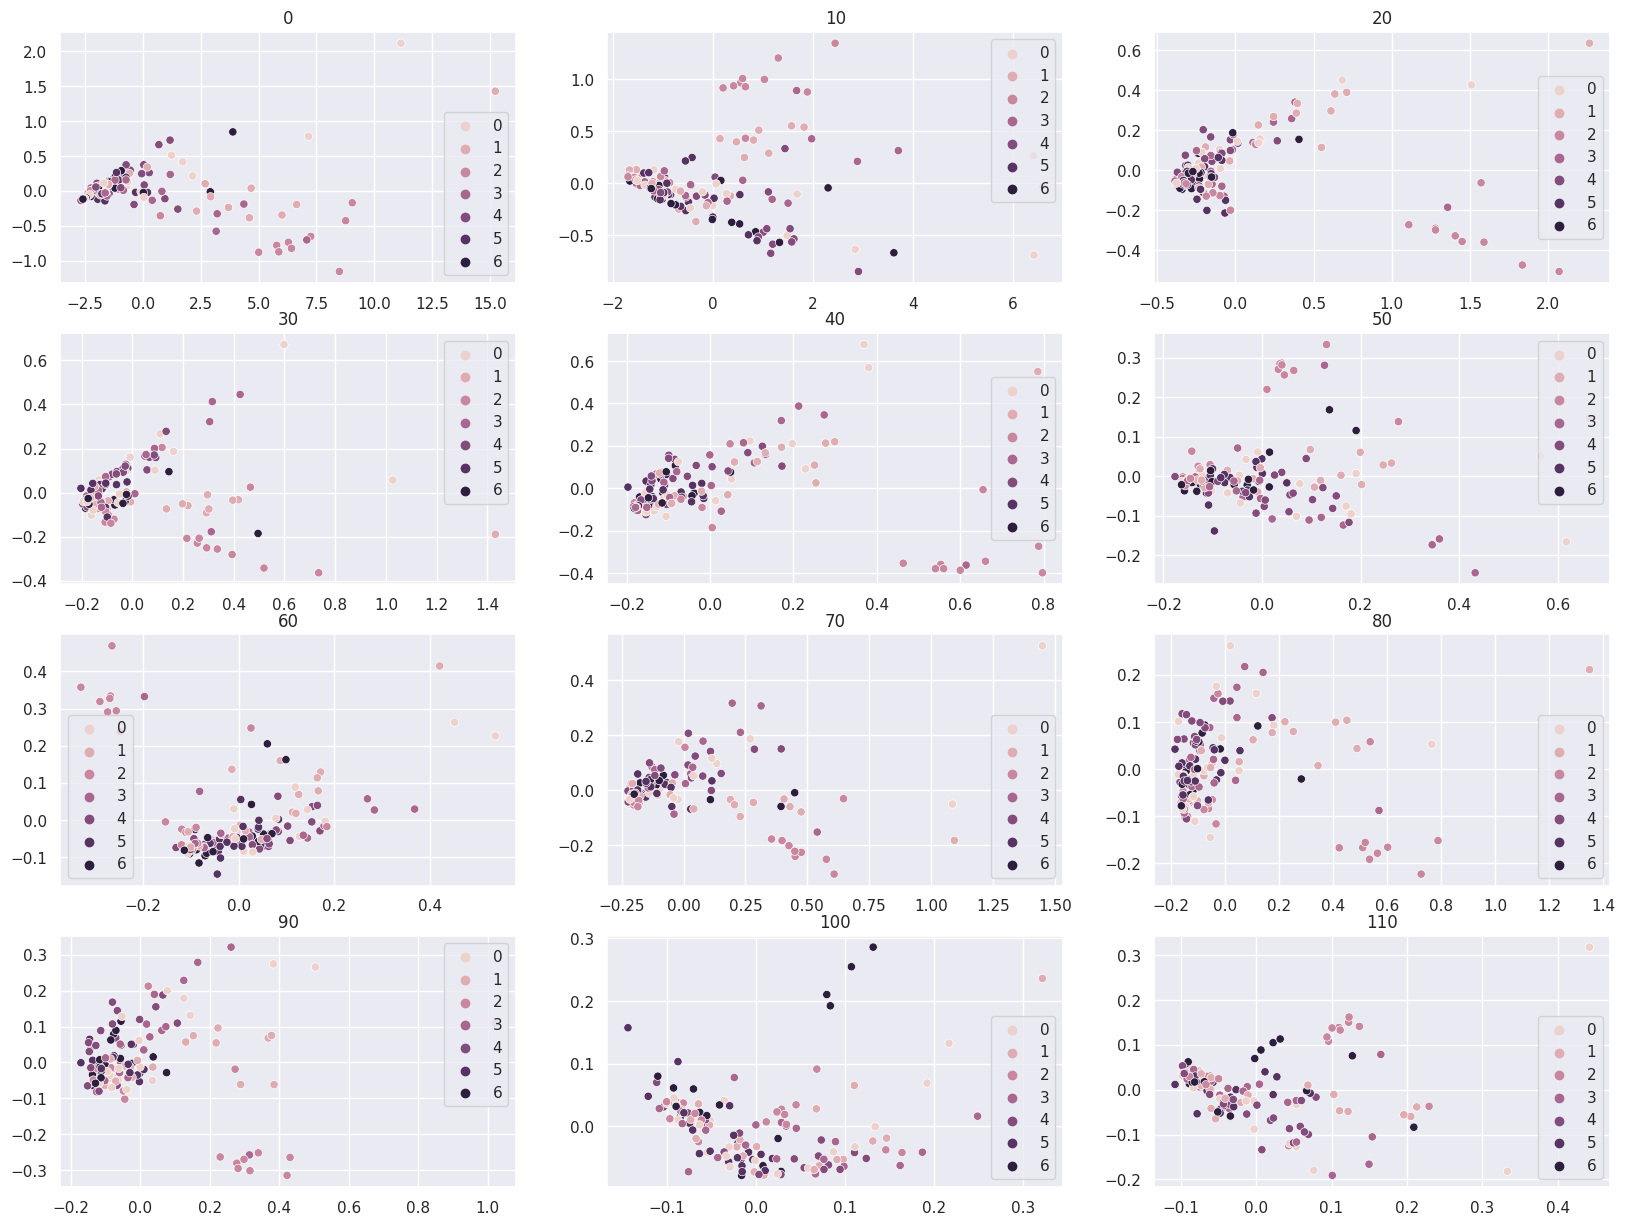

In [5]:
_, axes = plt.subplots(len(epochs) // 3, 3, figsize=(20, 15))  # , sharey=True, sharex=True)

for ax, rr, ll, ee in zip(axes.flatten(), reprs, labels, epochs):
    proj = PCA(n_components=2, random_state=1234).fit_transform(rr)
    sns.scatterplot(x=proj[:, 0], y=proj[:, 1], hue=ll, ax=ax)
    ax.set_title(ee)

plt.show()

# SVD analysis

In [6]:
svd_values = torch.linalg.svdvals(torch.stack(reprs))

[Text(0.5, 0, 'epoch'),
 Text(0, 0.5, '#above'),
 Text(0.5, 1.0, '#singular_values > 1e-05')]

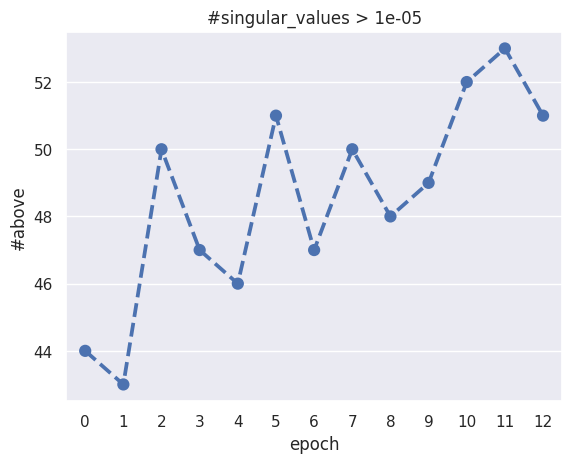

In [7]:
EPS = 1e-5
above_thresh = (svd_values > EPS).sum(dim=-1)
ax = sns.pointplot(x=np.arange(len(svd_values)), y=above_thresh.numpy(), linestyles="--")
# ax = sns.pointplot(x=epochs, y=above_thresh.numpy(), linestyles="--")
ax.set(xlabel="epoch", ylabel="#above", title=f"#singular_values > {EPS}")

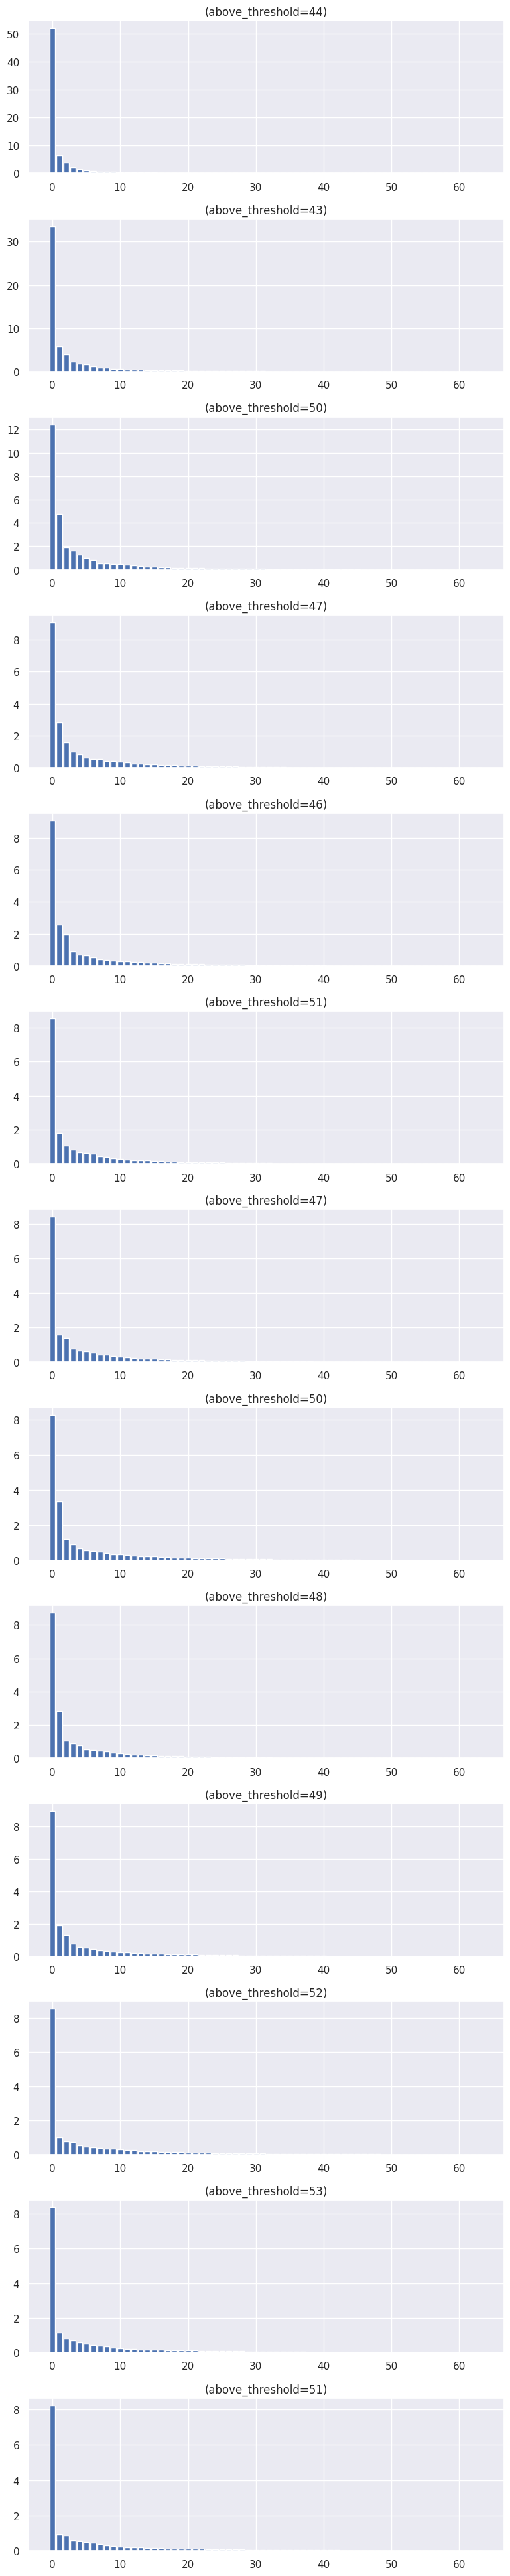

In [8]:
_, axes = plt.subplots(len(svd_values), 1, figsize=(8, len(svd_values) * 3), squeeze=False)

for ax, sv in zip(axes.flatten(), svd_values):
    ax.bar(x=np.arange(len(sv)), height=sv)

    non_zero_singulars = (sv > 1e-5).sum()
    ax.set_title(f"(above_threshold={non_zero_singulars})")

plt.tight_layout()
plt.show()